# 02. Naive Bayes — Gaussian e Bernoulli

Este notebook implementa e avalia dois modelos da família Naive Bayes aplicados ao dataset **Breast Cancer Wisconsin Diagnostic (WDBC)**:

- **Gaussian Naive Bayes (GaussianNB):** variante correta para dados numéricos contínuos. Assume que cada feature segue uma distribuição normal (gaussiana) dentro de cada classe.
- **Bernoulli Naive Bayes (BernoulliNB):** variante projetada para dados binários (0/1). Incluído como comparativo para evidenciar o impacto de escolher a variante inadequada para o tipo de dado.

O foco principal da análise é o **Recall da classe Maligno**, a métrica prioritária neste trabalho, dado que um falso negativo (tumor maligno classificado como benigno) tem custo clínico substancialmente maior que um falso positivo.

---
## 1. Importações e Configuração do Ambiente

In [ ]:
# 1. Importando bibliotecas e pipeline centralizado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pipeline import run_pipeline

from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score
)

Bibliotecas importadas com sucesso!


---
## 2. Carregamento dos Dados e Treinamento de Modelos

Os dados são carregados diretamente pelo pipeline centralizado do projeto, garantindo que todos os modelos utilizem exatamente o mesmo pré-processamento e os mesmos conjuntos de treino e teste.

In [39]:
# 2. Carregando os dados pré-processados e padronizados
X_train, X_test, y_train, y_test = run_pipeline()

# 3.1 Treinando o Gaussian Naive Bayes
# Variante correta para features numéricas contínuas
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 3.2 Treinando o Bernoulli Naive Bayes
# Variante para dados binários — incluído como comparativo
bnb = BernoulliNB()
bnb.fit(X_train, y_train)


BernoulliNB()

---
## 3. Previsões e Métricas de Avaliação

As previsões são geradas sobre o conjunto de teste. As métricas reportadas são **Precisão**, **Recall**, **F1-score** e **Acurácia**, com ênfase no Recall da classe Maligno.

In [40]:
# 4.1 Gerando previsões
y_pred_gnb  = gnb.predict(X_test)
y_proba_gnb = gnb.predict_proba(X_test)[:, 1]

y_pred_bnb  = bnb.predict(X_test)
y_proba_bnb = bnb.predict_proba(X_test)[:, 1]

In [41]:
# 4.2 Relatório de classificação — Gaussian Naive Bayes
print("=" * 50)
print("GAUSSIAN NAIVE BAYES")
print("=" * 50)
print(classification_report(y_test, y_pred_gnb, target_names=["Benigno", "Maligno"]))
print(f"Recall (Maligno): {recall_score(y_test, y_pred_gnb):.4f}")

GAUSSIAN NAIVE BAYES
              precision    recall  f1-score   support

     Benigno       0.92      0.96      0.94        72
     Maligno       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

Recall (Maligno): 0.8571


In [31]:
# 4.3 Relatório de classificação — Bernoulli Naive Bayes
print("=" * 50)
print("BERNOULLI NAIVE BAYES (modelo inadequado para o WDBC)")
print("=" * 50)
print(classification_report(y_test, y_pred_bnb, target_names=["Benigno", "Maligno"]))
print(f"Recall (Maligno): {recall_score(y_test, y_pred_bnb):.4f}")

BERNOULLI NAIVE BAYES (modelo inadequado para o WDBC)
              precision    recall  f1-score   support

     Benigno       0.93      0.96      0.95        72
     Maligno       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Recall (Maligno): 0.8810


In [32]:
# 4.4 Tabela comparativa consolidada
resultados = pd.DataFrame({
    "Modelo"   : ["GaussianNB", "BernoulliNB"],
    "Acurácia" : [accuracy_score(y_test, y_pred_gnb),  accuracy_score(y_test, y_pred_bnb)],
    "Precisão" : [precision_score(y_test, y_pred_gnb), precision_score(y_test, y_pred_bnb)],
    "Recall"   : [recall_score(y_test, y_pred_gnb),    recall_score(y_test, y_pred_bnb)],
    "F1-score" : [f1_score(y_test, y_pred_gnb),        f1_score(y_test, y_pred_bnb)],
}).round(4)

print("=== TABELA COMPARATIVA ===")
print(resultados.to_string(index=False))

=== TABELA COMPARATIVA ===
     Modelo  Acurácia  Precisão  Recall  F1-score
 GaussianNB    0.9211    0.9231  0.8571    0.8889
BernoulliNB    0.9298    0.9250  0.8810    0.9024


---
## 4. Matrizes de Confusão

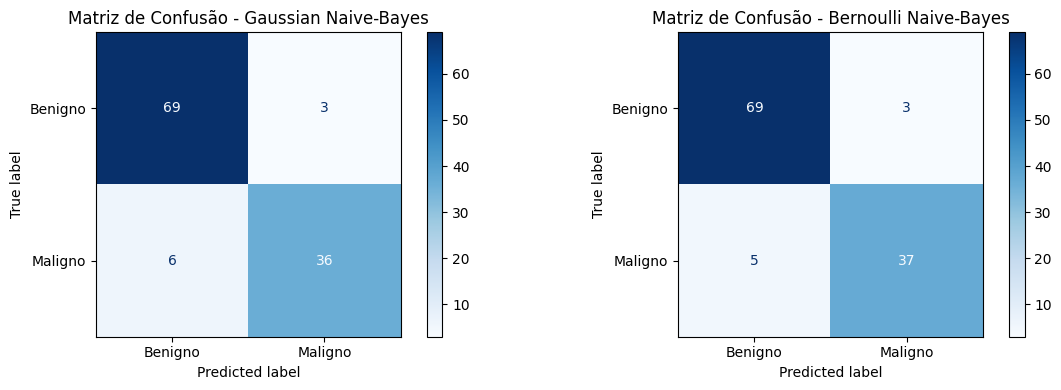

In [42]:
# 5. Gerando matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in zip(
    axes,
    [y_pred_gnb, y_pred_bnb],
    ["Matriz de Confusão - Gaussian Naive-Bayes", "Matriz de Confusão - Bernoulli Naive-Bayes"]
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(ax=ax, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("outputs/matriz_gnb_vs_bnb.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

---
## 5. Análise de Threshold — GaussianNB

Por padrão, modelos de classificação utilizam **threshold = 0.5**: o modelo classifica como Maligno apenas quando a probabilidade calculada supera 50%. 

No contexto clínico deste trabalho, reduzir o threshold significa tornar o modelo mais conservador, classificando como Maligno casos com menor certeza e, consequentemente, **reduzindo o número de falsos negativos** ao custo de aumentar os falsos positivos.


In [34]:
# 7.1 Distribuição das probabilidades preditas
print("Distribuição das probabilidades (classe Maligno):")
print(pd.Series(y_proba_gnb).describe())
print()
print("Casos com probabilidade entre 0.2 e 0.5:")
mascara = (y_proba_gnb >= 0.2) & (y_proba_gnb < 0.5)
print(f"Total: {mascara.sum()} casos")

Distribuição das probabilidades (classe Maligno):
count    1.140000e+02
mean     3.411757e-01
std      4.737677e-01
min      3.161010e-20
25%      8.548312e-16
50%      7.075852e-10
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Casos com probabilidade entre 0.2 e 0.5:
Total: 0 casos


In [35]:
# 7.2 Tabela de métricas por threshold
print("=== ANÁLISE DE THRESHOLD — GaussianNB ===")
print(f"{'Threshold':<12} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 65)

thresholds = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]
resultados_threshold = []

for t in thresholds:
    y_pred_t = (y_proba_gnb >= t).astype(int)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    fn   = confusion_matrix(y_test, y_pred_t)[1][0]
    print(f"{t:<12.2f} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_threshold.append((t, rec, prec, acc, f1, fn))

=== ANÁLISE DE THRESHOLD — GaussianNB ===
Threshold      Recall   Precisão   Acurácia       F1   Falsos Neg.
-----------------------------------------------------------------
0.50           0.8571     0.9231     0.9211   0.8889             6
0.45           0.8571     0.9231     0.9211   0.8889             6
0.40           0.8571     0.9231     0.9211   0.8889             6
0.35           0.8571     0.9231     0.9211   0.8889             6
0.30           0.8571     0.9231     0.9211   0.8889             6
0.25           0.8571     0.9231     0.9211   0.8889             6
0.20           0.8571     0.9231     0.9211   0.8889             6


A análise de threshold revelou que o GaussianNB produz probabilidades extremamente polarizadas. A maioria dos casos recebe probabilidade próxima de 0 ou de 1, sem casos intermediários. Isso sugere que o modelo é **mal calibrado**: as probabilidades retornadas não refletem a incerteza real.

Este comportamento é causado pela **violação da suposição de independência** entre features. O GaussianNB assume que todas as 30 features são independentes, mas o WDBC apresenta correlações acima de 0.98 entre features como `radius_mean`, `perimeter_mean` e `area_mean`. Quando features altamente correlacionadas são tratadas como independentes, suas probabilidades são multiplicadas repetidamente, empurrando os valores para os extremos.